In [1]:
from sklearn import datasets
data_breast_cancer = datasets.load_breast_cancer(as_frame=True)
print(data_breast_cancer['DESCR'])

.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

<Axes: xlabel='x', ylabel='y'>

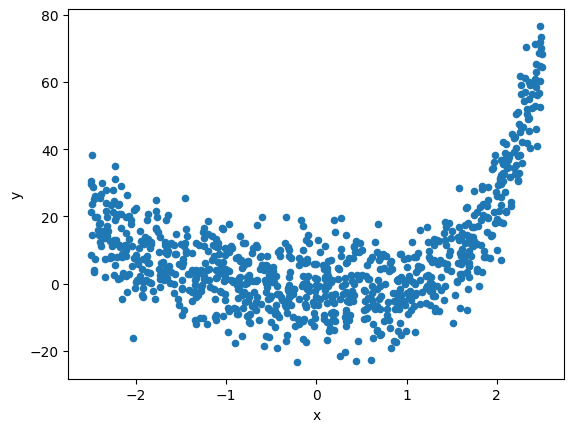

In [2]:
import numpy as np
import pandas as pd
size = 900
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})
df.plot.scatter(x='x',y='y')

In [3]:
from sklearn.model_selection import train_test_split

X = data_breast_cancer.data[['mean texture', 'mean symmetry']]
y = data_breast_cancer.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [4]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score

for i in range(2, 11):
    tree_clf = DecisionTreeClassifier(max_depth=i)
    tree_clf.fit(X_train, y_train)
    
    f1_train = f1_score(y_train, tree_clf.predict(X_train))
    print(f"F1-score dla zbioru uczącego (max_depth={i}) {f1_train}")
    f1_test = f1_score(y_test, tree_clf.predict(X_test))
    print(f"F1-score dla zbioru testującego (max_depth={i}) {f1_test} \n")



F1-score dla zbioru uczącego (max_depth=2) 0.8114901256732495
F1-score dla zbioru testującego (max_depth=2) 0.7922077922077922 

F1-score dla zbioru uczącego (max_depth=3) 0.823321554770318
F1-score dla zbioru testującego (max_depth=3) 0.8152866242038217 

F1-score dla zbioru uczącego (max_depth=4) 0.8321678321678322
F1-score dla zbioru testującego (max_depth=4) 0.8050314465408805 

F1-score dla zbioru uczącego (max_depth=5) 0.8487084870848709
F1-score dla zbioru testującego (max_depth=5) 0.7870967741935484 

F1-score dla zbioru uczącego (max_depth=6) 0.8776978417266187
F1-score dla zbioru testującego (max_depth=6) 0.7898089171974523 

F1-score dla zbioru uczącego (max_depth=7) 0.8990825688073395
F1-score dla zbioru testującego (max_depth=7) 0.7631578947368421 

F1-score dla zbioru uczącego (max_depth=8) 0.9261992619926199
F1-score dla zbioru testującego (max_depth=8) 0.7210884353741497 

F1-score dla zbioru uczącego (max_depth=9) 0.948339483394834
F1-score dla zbioru testującego (max_

In [5]:
from sklearn.tree import export_graphviz
import graphviz

tree_clf = DecisionTreeClassifier(max_depth=3)
tree_clf.fit(X_train, y_train)

str_dot = export_graphviz(
    tree_clf,
    out_file=None, 
    feature_names=data_breast_cancer.feature_names[[1, 8]],
    class_names=[str(num) + ", " + name for num, name in zip(set(data_breast_cancer.target), data_breast_cancer.target_names)],
    rounded=True,
    filled=True
)

graph = graphviz.Source(str_dot)
graph.render("bc", format="png", cleanup=True)

'bc.png'

In [6]:
from sklearn.metrics import accuracy_score
import pickle

f1_train = f1_score(y_train, tree_clf.predict(X_train))
f1_test = f1_score(y_test, tree_clf.predict(X_test))
acc_train = accuracy_score(y_train, tree_clf.predict(X_train))
acc_test = accuracy_score(y_test, tree_clf.predict(X_test))

f1acc_tree = [3, f1_train, f1_test, acc_train, acc_test]

with open('f1acc_tree.pkl', 'wb') as f:
    pickle.dump(f1acc_tree, f)

In [7]:
size = 900
X = np.random.rand(size)*5-2.5
w4, w3, w2, w1, w0 = 1, 2, 1, -4, 2
y = w4*(X**4) + w3*(X**3) + w2*(X**2) + w1*X + w0 + np.random.randn(size)*8-4
df = pd.DataFrame({'x': X, 'y': y})

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)

In [8]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

for i in range(2, 11):
    tree_reg = DecisionTreeRegressor(max_depth=i)
    tree_reg.fit(X_train, y_train)

    mse_train = mean_squared_error(y_train, tree_reg.predict(X_train))
    print(f"MSE dla zbioru uczącego (max_depth={i}) {mse_train}")
    mse_test = mean_squared_error(y_test, tree_reg.predict(X_test))
    print(f"MSE dla zbioru testującego (max_depth={i}) {mse_test} \n")
    

MSE dla zbioru uczącego (max_depth=2) 85.53165608717929
MSE dla zbioru testującego (max_depth=2) 110.80840448504468 

MSE dla zbioru uczącego (max_depth=3) 66.2228759606865
MSE dla zbioru testującego (max_depth=3) 82.54891797589458 

MSE dla zbioru uczącego (max_depth=4) 57.72174909816318
MSE dla zbioru testującego (max_depth=4) 72.55016961396728 

MSE dla zbioru uczącego (max_depth=5) 53.29167590298788
MSE dla zbioru testującego (max_depth=5) 72.83298756354121 

MSE dla zbioru uczącego (max_depth=6) 49.036930027956146
MSE dla zbioru testującego (max_depth=6) 76.76435665040798 

MSE dla zbioru uczącego (max_depth=7) 44.72045528226476
MSE dla zbioru testującego (max_depth=7) 87.55792086206891 

MSE dla zbioru uczącego (max_depth=8) 38.81920352843474
MSE dla zbioru testującego (max_depth=8) 89.100748367539 

MSE dla zbioru uczącego (max_depth=9) 33.48020911264833
MSE dla zbioru testującego (max_depth=9) 91.66464812783985 

MSE dla zbioru uczącego (max_depth=10) 29.731528258968652
MSE dla

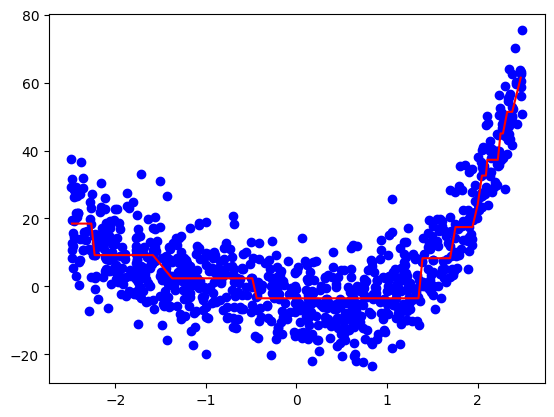

In [9]:
import matplotlib.pyplot as plt

tree_reg = DecisionTreeRegressor(max_depth=4)
tree_reg.fit(X_train, y_train)

plt.clf()
plt.scatter(X, y, c="blue")
sort_index = np.argsort(X_test[:, 0])
plt.plot(X_test[sort_index], tree_reg.predict(X_test[sort_index]), c="red")

In [10]:
str_dot = export_graphviz(
    tree_reg,
    out_file=None, 
    feature_names=['x'],
    rounded=True,
    filled=True
)

graph = graphviz.Source(str_dot)
graph.render("reg", format="png", cleanup=True)

'reg.png'

In [11]:
mse_train = mean_squared_error(y_train, tree_reg.predict(X_train))
mse_test = mean_squared_error(y_test, tree_reg.predict(X_test))

mse_tree = [4, mse_train, mse_test]

with open('mse_tree.pkl', 'wb') as f:
    pickle.dump(mse_tree, f)